SWC Lab meeting plots:
- diff in prediction accuracy bars, sessions and mouse averages [done]
- diff in prediction accuracy first and second half [done]
- diff in prediction accuracy first and second half but for the first session [done]

Supplementary:
- pred.acc. diff over time [done]
- pred acc. diff top to bottom of arena [done]
- compare to homings
- is the pa of postflip increasing or preflip decreasing?

In [103]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

barrier_sesh_by_mouse = {'JAL003': ['2023_08_22','2023_08_25','2023_08_29','2023_09_01','2023_09_04','2023_09_07'],
                         'JAL004': ['2023_08_21','2023_08_24','2023_08_28','2023_09_03','2023_09_11','2023_09_19'],
                         'JAL005': ['2023_09_05','2023_09_08','2023_09_14','2023_09_21','2023_09_26','2023_09_28'],
                         'JAL006': ['2024_03_11','2024_03_14','2024_03_18','2024_03_21','2024_03_25','2024_03_28','2024_04_01','2024_04_05'],
                         'JAL007': ['2024_03_12','2024_03_15','2024_03_19','2024_03_22','2024_03_26','2024_04_04','2024_04_09','2024_04_16','2024_04_23'],
                         'JAL008': ['2024_04_25','2024_04_29','2024_05_7','2024_05_10','2024_05_14']}

In [9]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import tracking_to_features, extract_pa_across_sesh

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\SWClabmeeting"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']
settings = 'all_angles_fr'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

In [104]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

Preflip vs Postflip

In [105]:
"""Mouse averages"""
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_pa = {}
for key in pa.keys():
    if key not in m_pa:
        m_pa[key] = np.zeros((len(unique_mouse),3))
for idx, a in enumerate(all_angles):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_pa[a][m_idx,:] = np.mean(pa[a][this_mouse,:], axis=0)

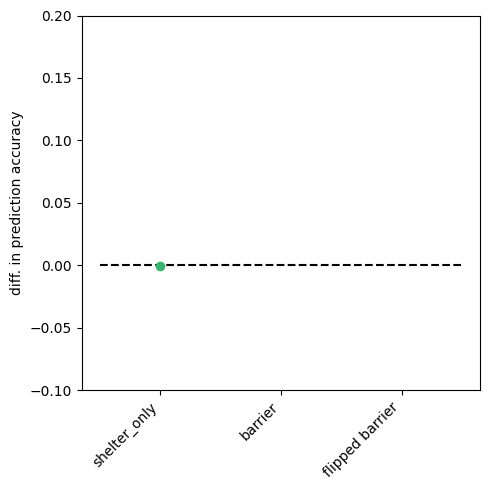

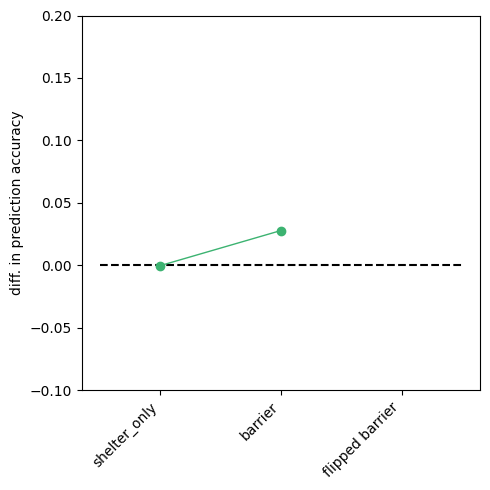

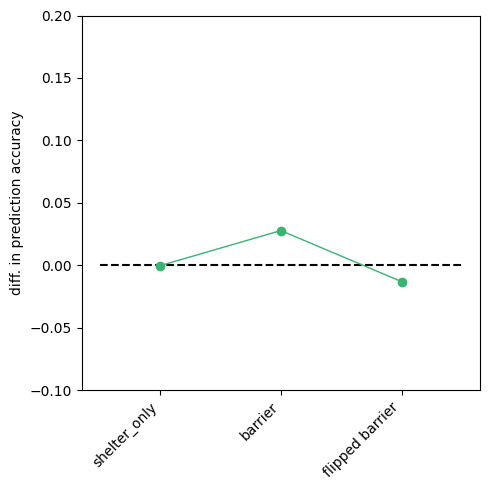

In [106]:
''' Plot the difference in pa for two goals'''
c = ['h_preflipbar_a','h_postflipbar_a']
# good = [0, 7, 9, 14, 19,22,25]
diff = pa[c[0]] - pa[c[1]]
idx = 0
p = diff[idx,:]

fig, axs = plt.subplots(1,1,figsize = (5,5))
axs.plot([-.5,2.5],[0,0],'--k')
axs.plot(conditions[:1],p[:1],color = 'mediumseagreen',alpha = 1, linewidth = 1, marker = 'o')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(['shelter_only','barrier','flipped barrier'],rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('diff. in prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff1_'+all_names[idx]+'_'+settings+'.png'))

fig, axs = plt.subplots(1,1,figsize = (5,5))
axs.plot([-.5,2.5],[0,0],'--k')
axs.plot(conditions[:2],p[:2],color = 'mediumseagreen',alpha = 1, linewidth = 1, marker = 'o')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(['shelter_only','barrier','flipped barrier'],rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('diff. in prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff2_'+all_names[idx]+'_'+settings+'.png'))

fig, axs = plt.subplots(1,1,figsize = (5,5))
axs.plot([-.5,2.5],[0,0],'--k')
axs.plot(conditions,p,color = 'mediumseagreen',alpha = 1, linewidth = 1, marker = 'o')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(['shelter_only','barrier','flipped barrier'],rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('diff. in prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff3_'+all_names[idx]+'_'+settings+'.png'))


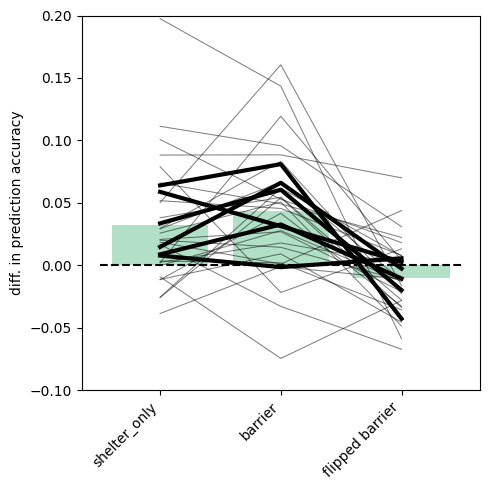

In [107]:
''' Plot the difference in pa for two goals'''
c = ['h_preflipbar_a','h_postflipbar_a']

fig, axs = plt.subplots(1,1,figsize = (5,5))

diff = pa[c[0]] - pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .4)
for p in diff:
    axs.plot(conditions,p,color = 'k',alpha = .5, linewidth = .75)
axs.plot([-.5,2.5],[0,0],'--k')
# axs.set_title(c[0] + ' - ' + c[1]  +  
#                     '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
#                     '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
#                     fontsize = 10)
diff = m_pa[c[0]] - m_pa[c[1]]
for m, p in enumerate(diff):
    axs.plot(conditions, p, linewidth = 3, label = unique_mouse[m], color = 'k')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(['shelter_only','barrier','flipped barrier'],rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('diff. in prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'.png'))

Top vs bottom

In [108]:
"""Mouse averages"""
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_avg_pa = {}
for key in avg_pa.keys():
    if key not in m_pa:
        m_avg_pa[key] = np.zeros((len(unique_mouse),3))
for idx, a in enumerate(avg_pa.keys()):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_avg_pa[a][m_idx,:] = np.mean(avg_pa[a][this_mouse,:], axis=0)

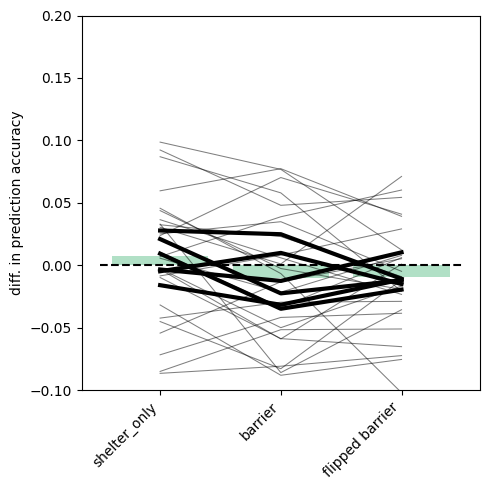

In [109]:
''' Plot the difference in pa for two goals'''
c = ['arena_bottom', 'arena_top']

fig, axs = plt.subplots(1,1,figsize = (5,5))

diff = avg_pa[c[0]] - avg_pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .4)
for p in diff:
    axs.plot(conditions,p,color = 'k',alpha = .5, linewidth = .75)
axs.plot([-.5,2.5],[0,0],'--k')
# axs.set_title(c[0] + ' - ' + c[1]  +  
#                     '\n in ' + str(np.sum(diff[:,1]>0)) + '/' + str(len(pa[c[0]])) + ' ' + c[0] + ' pa is greater in preflip' +
#                     '\n in ' + str(np.sum(diff[:,2]<0)) + '/' + str(len(pa[c[0]])) + ' ' + c[1] + ' pa is greater in postflip',
#                     fontsize = 10)
diff = m_avg_pa[c[0]] - m_avg_pa[c[1]]
for m, p in enumerate(diff):
    axs.plot(conditions, p, linewidth = 3, label = unique_mouse[m], color = 'k')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(['shelter_only','barrier','flipped barrier'],rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('diff. in prediction accuracy')
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_bttom_top_diff_allsesh_'+settings+'.png'))

Across sessions

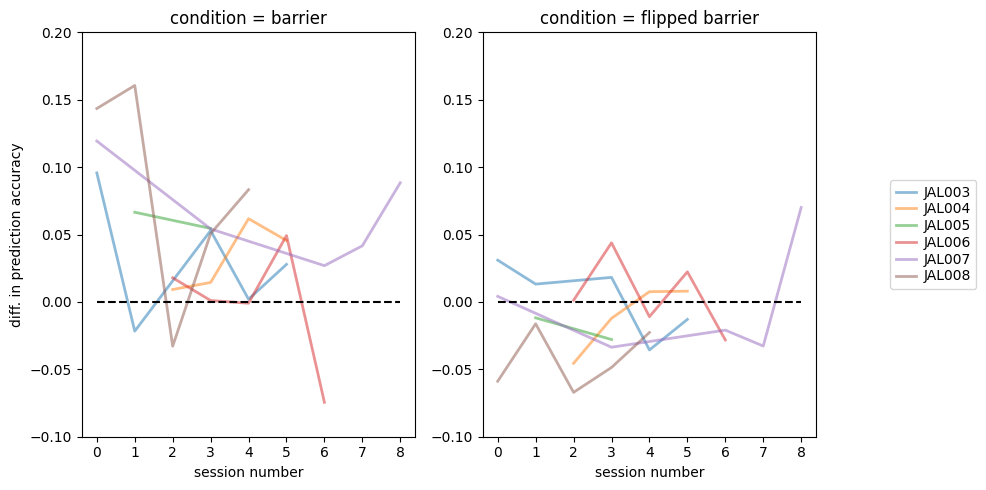

In [75]:
'''Find for each mouse the sessions in order and plot the prediction accuracy,
labeled by which barrier sessions this is'''
mouse = ['JAL003','JAL004','JAL005','JAL006','JAL007','JAL008']
diff = pa['h_preflipbar_a'] - pa['h_postflipbar_a']

fig, axs = plt.subplots(1,2, figsize = (10,5))

for m in mouse:
    this_m = [c for c in all_names if m in c]
    this_m_idx = []
    for sesh in this_m:
        this_m_idx.append([i for i,m in enumerate(barrier_sesh_by_mouse[m]) if m in sesh][0])
    this_m_idx = np.array(this_m_idx)
    sort_idx = np.argsort(this_m_idx)
    this_m_val = np.array([d for c,d in zip(all_names,diff[:,1]) if m in c]) # preflip
    axs[0].plot(this_m_idx[sort_idx],this_m_val[sort_idx], linewidth = 2, alpha = .5)
    this_m_val = np.array([d for c,d in zip(all_names,diff[:,2]) if m in c]) # postflip
    axs[1].plot(this_m_idx[sort_idx],this_m_val[sort_idx], linewidth = 2, alpha = .5)

axs[0].set_ylabel('diff. in prediction accuracy')
axs[0].set_title('condition = barrier')
axs[1].set_title('condition = flipped barrier')
axs[1].legend(mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
for i in [0,1]: 
    axs[i].plot([0,8],[0,0],'--k')
    axs[i].set_xlabel('session number')
    axs[i].set_xticks(np.arange(0,9,1))
    axs[i].set_ylim([-.1,.2])

plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'_overtime.png'))

First half vs second half

In [76]:
time_cond = ["first_half", "second_half"]
sessy, all_names, avg_pa, pa = extract_pa_across_sesh(
    all_angles, experiments_objects, conditions, all_features, settings, bar_angles=False, time_cond=time_cond
)

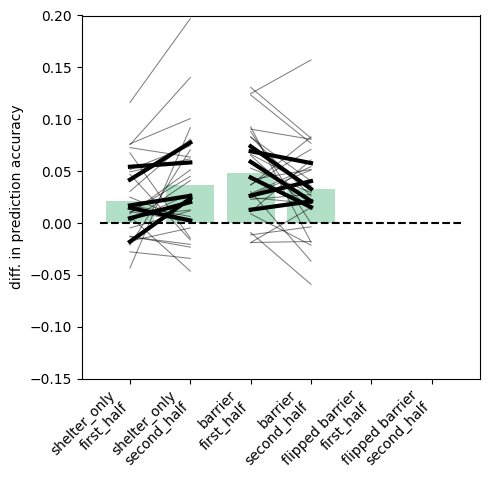

In [93]:
'''Plot diff in prediction accuracy in first vs second half averaged by mouse'''
fig, axs = plt.subplots(1,1, figsize = (5,5))
angle = ['h_preflipbar_a','h_postflipbar_a']
cond = ['shelter_only','barrier','flipped barrier']
aligned = []
name = []
for c_idx, c in enumerate(conditions):
    for t_idx, t in enumerate(time_cond):
        if len(aligned) == 0:
            aligned = pa[angle[0]][:,c_idx,t_idx] - pa[angle[1]][:,c_idx,t_idx]
        else:
            aligned = np.vstack((aligned, pa[angle[0]][:,c_idx,t_idx] - pa[angle[1]][:,c_idx,t_idx]))
        name.append(str(cond[c_idx] + '\n' + t))

aligned = np.delete(aligned,15,1)

not_all_names = all_names[:15] + all_names[16:]
mouse_ID = [x[:6] for x in not_all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_aligned = np.zeros((len(unique_mouse),np.shape(aligned)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_aligned[m_idx,:] = np.mean(aligned[:,this_mouse], axis=1)

for i in [0,2,4]:
    axs.bar(name[i:i+2],np.nanmean(aligned[i:i+2,:],axis=1),color = 'mediumseagreen',alpha = .4)
    axs.plot(name[i:i+2],aligned[i:i+2,:],color = 'k',alpha = .5, linewidth = .75)
    axs.plot(name[i:i+2],mean_aligned[:,i:i+2].T, linewidth = 3, color = 'k')
axs.plot([-.5,np.shape(aligned)[0]-.5],[0,0],'--k')
axs.set_xticks(np.arange(np.shape(aligned)[0]))
axs.set_xticklabels(name,rotation = 45, ha="right")
axs.set_ylabel('diff. in prediction accuracy')
axs.set_ylim([-.15,.2])
plt.tight_layout()
plt.savefig(save_path+'/'+str('diff_pa_first_second_half_all_avg.png'))

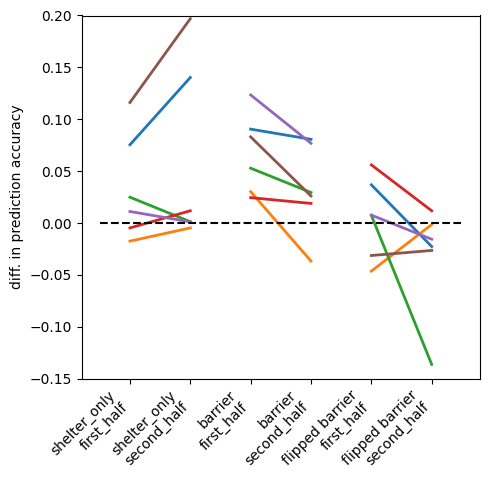

In [102]:
first_sesh_by_mouse = ['JAL003_2023_08_22','JAL004_2023_08_28','JAL005_2023_09_08','JAL006_2024_03_18','JAL007_2024_03_12','JAL008_2024_04_25']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axs = plt.subplots(1,1, figsize = (5,5))
for f_idx, f in enumerate(first_sesh_by_mouse):
    idx = [i for i,s in enumerate(not_all_names) if s == f]
    for i in [0,2,4]:
        axs.plot(name[i:i+2],aligned[i:i+2,idx], linewidth = 2, color = colors[f_idx])

axs.plot([-.5,np.shape(aligned)[0]-.5],[0,0],'--k')
axs.set_xticks(np.arange(np.shape(aligned)[0]))
axs.set_xticklabels(name,rotation = 45, ha="right")
axs.set_ylabel('diff. in prediction accuracy')
axs.set_ylim([-.15,.2])
plt.tight_layout()
plt.savefig(save_path+'/'+str('diff_pa_first_second_half_first_sesh.png'))

In [ ]:
"""Is preflip prediction accuracy increasing? Is postflip decreasing?"""
fig, axs = plt.subplots(1,2, figsize = (10,5))
angle = ['h_preflipbar_a','h_postflipbar_a']
cond = ['shelter_only','barrier','flipped barrier']
pre_aligned = []
post_aligned = []
name = []
for c_idx, c in enumerate(conditions):
    if len(aligned) == 0:
        pre_aligned = pa[angle[0]][:,c_idx,time_cond[1]] - pa[angle[0]][:,c_idx,time_cond[0]]
        post_aligned = pa[angle[1]][:,c_idx,time_cond[1]] - pa[angle[1]][:,c_idx,time_cond[0]]
    else:
        pre_aligned = np.vstack((pre_aligned, pa[angle[0]][:,c_idx,time_cond[1]] - pa[angle[0]][:,c_idx,time_cond[0]]))
        post_aligned = np.vstack((post_aligned,pa[angle[1]][:,c_idx,time_cond[1]] - pa[angle[1]][:,c_idx,time_cond[0]]))
    name.append(str(cond[c_idx]))

pre_aligned = np.delete(pre_aligned,15,1)
post_aligned = np.delete(post_aligned,15,1)

not_all_names = all_names[:15] + all_names[16:]
mouse_ID = [x[:6] for x in not_all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_pre_aligned = np.zeros((len(unique_mouse),np.shape(aligned)[0]))
mean_post_aligned = np.zeros((len(unique_mouse),np.shape(aligned)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_pre_aligned[m_idx,:] = np.mean(pre_aligned[:,this_mouse], axis=1)
    mean_post_aligned[m_idx,:] = np.mean(post_aligned[:,this_mouse], axis=1)

# plot the pred acc preflip
axs.bar(name,np.nanmean(aligned,axis=1),color = 'mediumseagreen',alpha = .4)
axs.plot(name,aligned,color = 'k',alpha = .5, linewidth = .75)
axs.plot(name,mean_aligned.T, linewidth = 3, color = 'k')
axs.plot([-.5,np.shape(aligned)[0]-.5],[0,0],'--k')
axs.set_xticks(np.arange(np.shape(aligned)[0]))
axs.set_xticklabels(name,rotation = 45, ha="right")
axs.set_ylabel('diff. in prediction accuracy')
axs.set_ylim([-.15,.2])
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_change_first_second_half_all_avg.png'))